In [1]:
import os
import re
import glob
import pandas as pd
from IPython.display import display, Markdown
from collections import OrderedDict
import pylhe
from scipy.interpolate import griddata
from scipy.interpolate import interp1d
import pyslha
import xml.etree.ElementTree as ET
import pyslha
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

defaultPars = {'figure.figsize': (5, 4), 'lines.markersize' : 4, 'axes.titlesize' : 13, 'font.size' : 13,
               'axes.labelsize' : 16, 'xtick.labelsize' : 13, 'ytick.labelsize' : 13, 'legend.fontsize' : 10,
               "text.usetex": True, "font.family": "sans-serif", "font.sans-serif": ["Helvetica"],
               'font.family':'Times New Roman', 'font.serif':'Times New Roman', "savefig.dpi" : 300,
               'contour.linewidth' : 2.0, 'lines.linewidth' : 2.0, 'axes.grid' : True,
               'grid.linewidth' : 0.5, 'grid.color' : 'lightgray', 'axes.axisbelow' : True
               }
plt.rcParams.update(defaultPars) #Figure resolution
pd.set_option('display.max_rows', 200)

cm = plt.colormaps['RdYlBu']


In [2]:
pd.read_pickle('/home/ramos/ma5Results_axial.pcl')

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Efficiency,Stat,Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV)
0,IM0,8.534284,8.538081,0.094503,0.004867,0.000260,dma_1000_10,10.0,1000.0
1,IM1,4.409492,4.414570,0.072209,0.004306,0.000260,dma_1000_10,10.0,1000.0
2,IM2,3.336647,3.345726,0.054157,0.003766,0.000260,dma_1000_10,10.0,1000.0
3,IM3,2.449853,2.464980,0.040794,0.003291,0.000260,dma_1000_10,10.0,1000.0
4,IM4,2.141699,2.165333,0.029762,0.002827,0.000260,dma_1000_10,10.0,1000.0
...,...,...,...,...,...,...,...,...,...
2049,EM8,1.148875,1.224121,0.000775,0.000021,0.133546,dma_500_995,995.0,500.0
2050,EM9,1.150160,1.036460,0.000387,0.000015,0.133546,dma_500_995,995.0,500.0
2051,EM10,2.043404,3.589709,0.000194,0.000010,0.133546,dma_500_995,995.0,500.0
2052,EM11,2.679273,2.945245,0.000083,0.000007,0.133546,dma_500_995,995.0,500.0


In [3]:
pd.read_pickle('/home/ramos/ma5Results_axial_add.pcl')

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Efficiency,Stat,Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV)
0,IM0,41.562392,41.576814,0.018532,0.000012,8.470793,dma_100_10,10.0,100.0
1,IM1,26.835339,26.859584,0.011368,0.000010,8.470793,dma_100_10,10.0,100.0
2,IM2,25.132638,25.183693,0.006690,0.000008,8.470793,dma_100_10,10.0,100.0
3,IM3,21.957866,22.056093,0.004130,0.000006,8.470793,dma_100_10,10.0,100.0
4,IM4,22.766144,22.943636,0.002472,0.000005,8.470793,dma_100_10,10.0,100.0
...,...,...,...,...,...,...,...,...,...
1711,EM8,0.789179,0.842512,0.001128,0.000095,0.009061,dma_600_750,750.0,600.0
1712,EM9,0.578438,0.521256,0.000770,0.000078,0.009061,dma_600_750,750.0,600.0
1713,EM10,1.118858,2.396994,0.000358,0.000053,0.009061,dma_600_750,750.0,600.0
1714,EM11,0.808475,0.889602,0.000275,0.000047,0.009061,dma_600_750,750.0,600.0


In [4]:
df1 = pd.read_pickle('/home/ramos/ma5Results_axial.pcl')
df2 = pd.read_pickle('/home/ramos/ma5Results_axial_add.pcl')
dfs = [df1, df2]

df_final_results = pd.concat(dfs, ignore_index=True)

In [5]:
df_final_results[df_final_results['Signal Region'] == 'EM0']

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Efficiency,Stat,Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV)
13,EM0,-1.000000,-1.000000,0.022294,2.456300e-03,0.000260,dma_1000_10,10.0,1000.0
39,EM0,20.168789,20.174642,0.021526,2.050000e-03,0.000359,dma_1000_1000,1000.0,1000.0
65,EM0,20.275748,20.281665,0.021413,1.832800e-03,0.000447,dma_1000_1250,1250.0,1000.0
91,EM0,18.896161,18.901646,0.022976,1.607500e-03,0.000621,dma_1000_1500,1500.0,1000.0
117,EM0,20.148577,20.154425,0.021548,1.196600e-03,0.001066,dma_1000_1750,1750.0,1000.0
143,EM0,21.566225,21.572484,0.020131,5.961000e-04,0.003978,dma_1000_1995,1995.0,1000.0
169,EM0,18.609005,18.614342,0.023277,2.467000e-04,0.026804,dma_1000_2250,2250.0,1000.0
195,EM0,-1.000000,-1.000000,0.020796,2.356000e-03,0.000262,dma_1000_250,250.0,1000.0
221,EM0,17.321567,17.326527,0.025001,2.495000e-04,0.028303,dma_1000_2500,2500.0,1000.0
247,EM0,17.093556,17.098513,0.025394,2.925000e-04,0.020841,dma_1000_2750,2750.0,1000.0


In [6]:
df_final_results.columns

Index(['Signal Region', 'Sigma_95_exp (pb)', 'Sigma_95_obs (pb)', 'Efficiency',
       'Stat', 'Sigma_theoretical (pb)', 'SAF File', 'mMed (GeV)',
       'mchi (GeV)'],
      dtype='object')

In [7]:
df_final_results.sort_values(by=['mchi (GeV)', 'mMed (GeV)'], inplace=True)

In [8]:
df_final_results.T

,1378,1379,1380,1381,1382,1383,1384,1385,1386,1387,...,952,953,954,955,956,957,958,959,960,961
Signal Region,IM0,IM1,IM2,IM3,IM4,IM5,IM6,IM7,IM8,IM9,...,EM3,EM4,EM5,EM6,EM7,EM8,EM9,EM10,EM11,EM12
Sigma_95_exp (pb),48565.406779,47861.610571,1014.284119,957.228842,950.494336,1975.754282,954.975965,370.146638,-1.0,-1.0,...,2.788906,2.208678,1.04401,0.93172,0.730917,0.503204,0.450745,0.490895,0.444358,0.292209
Sigma_95_obs (pb),48565.406779,47861.610571,53286.489217,961.511612,957.899246,1999.353407,970.687777,375.71978,-1.0,-1.0,...,2.816025,2.256133,1.076273,1.007545,0.851978,0.539959,0.406186,1.061216,0.490992,0.24943
Efficiency,0.001066,0.000474,0.000166,0.000095,0.000059,0.000012,0.000012,0.000012,0.0,0.0,...,0.010887,0.01271,0.007536,0.004506,0.002773,0.001772,0.000989,0.000822,0.000501,0.000783
Stat,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000625,0.000675,0.000521,0.000403,0.000317,0.000253,0.000189,0.000173,0.000135,0.000169
Sigma_theoretical (pb),27247.13,27247.13,27247.13,27247.13,27247.13,27247.13,27247.13,27247.13,27247.13,27247.13,...,0.001995,0.001995,0.001995,0.001995,0.001995,0.001995,0.001995,0.001995,0.001995,0.001995
SAF File,dma_1_100,dma_1_100,dma_1_100,dma_1_100,dma_1_100,dma_1_100,dma_1_100,dma_1_100,dma_1_100,dma_1_100,...,dma_1400_3000,dma_1400_3000,dma_1400_3000,dma_1400_3000,dma_1400_3000,dma_1400_3000,dma_1400_3000,dma_1400_3000,dma_1400_3000,dma_1400_3000
mMed (GeV),100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,...,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0
mchi (GeV),1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1400.0,1400.0,1400.0,1400.0,1400.0,1400.0,1400.0,1400.0,1400.0,1400.0


In [9]:
k_factor = 1.1
df_final_results['$r_{obs}$'] =  (k_factor*df_final_results['Sigma_theoretical (pb)'] ) / df_final_results['Sigma_95_obs (pb)']
df_final_results['$r_{exp}$'] =   (k_factor*df_final_results['Sigma_theoretical (pb)']) / df_final_results['Sigma_95_exp (pb)']
# df_final_results['Status Obs'] = df_final_results['$\mu_{obs}$'].apply(lambda x: 'Included' if x > 1 else 'Excluded')
# df_final_results['Status Exp'] = df_final_results['$\mu_{exp}$'].apply(lambda x: 'Included' if x > 1 else 'Excluded')
df_final_results


,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Efficiency,Stat,Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),$r_{obs}$,$r_{exp}$
1378,IM0,48565.406779,48565.406779,0.001066,1.000000e-07,27247.130000,dma_1_100,100.0,1.0,0.617144,0.617144
1379,IM1,47861.610571,47861.610571,0.000474,0.000000e+00,27247.130000,dma_1_100,100.0,1.0,0.626219,0.626219
1380,IM2,1014.284119,53286.489217,0.000166,0.000000e+00,27247.130000,dma_1_100,100.0,1.0,0.562466,29.549751
1381,IM3,957.228842,961.511612,0.000095,0.000000e+00,27247.130000,dma_1_100,100.0,1.0,31.171587,31.311053
1382,IM4,950.494336,957.899246,0.000059,0.000000e+00,27247.130000,dma_1_100,100.0,1.0,31.289139,31.532900
...,...,...,...,...,...,...,...,...,...,...,...
957,EM8,0.503204,0.539959,0.001772,2.533000e-04,0.001995,dma_1400_3000,3000.0,1400.0,0.004064,0.004361
958,EM9,0.450745,0.406186,0.000989,1.893000e-04,0.001995,dma_1400_3000,3000.0,1400.0,0.005403,0.004869
959,EM10,0.490895,1.061216,0.000822,1.726000e-04,0.001995,dma_1400_3000,3000.0,1400.0,0.002068,0.004470
960,EM11,0.444358,0.490992,0.000501,1.347000e-04,0.001995,dma_1400_3000,3000.0,1400.0,0.004470,0.004939


In [10]:
# df_onshell = df_final_results[df_final_results['mMed (GeV)'] >= 2*df_final_results['mchi (GeV)']]
df_onshell = df_final_results

In [11]:
df_onshell = df_onshell[df_onshell['mchi (GeV)'] != 150.]

In [12]:
df_onshell

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Efficiency,Stat,Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),$r_{obs}$,$r_{exp}$
1378,IM0,48565.406779,48565.406779,0.001066,1.000000e-07,27247.130000,dma_1_100,100.0,1.0,0.617144,0.617144
1379,IM1,47861.610571,47861.610571,0.000474,0.000000e+00,27247.130000,dma_1_100,100.0,1.0,0.626219,0.626219
1380,IM2,1014.284119,53286.489217,0.000166,0.000000e+00,27247.130000,dma_1_100,100.0,1.0,0.562466,29.549751
1381,IM3,957.228842,961.511612,0.000095,0.000000e+00,27247.130000,dma_1_100,100.0,1.0,31.171587,31.311053
1382,IM4,950.494336,957.899246,0.000059,0.000000e+00,27247.130000,dma_1_100,100.0,1.0,31.289139,31.532900
...,...,...,...,...,...,...,...,...,...,...,...
957,EM8,0.503204,0.539959,0.001772,2.533000e-04,0.001995,dma_1400_3000,3000.0,1400.0,0.004064,0.004361
958,EM9,0.450745,0.406186,0.000989,1.893000e-04,0.001995,dma_1400_3000,3000.0,1400.0,0.005403,0.004869
959,EM10,0.490895,1.061216,0.000822,1.726000e-04,0.001995,dma_1400_3000,3000.0,1400.0,0.002068,0.004470
960,EM11,0.444358,0.490992,0.000501,1.347000e-04,0.001995,dma_1400_3000,3000.0,1400.0,0.004470,0.004939


In [13]:
max_sigma_exp_per_saf = df_onshell.loc[
    df_onshell.groupby('SAF File')['$r_{exp}$'].idxmax()   #mu_exp_max
]

max_sigma_exp_per_saf


,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Efficiency,Stat,Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),$r_{obs}$,$r_{exp}$
25,EM12,0.392707,0.335259,0.000583,4.015000e-04,0.000260,dma_1000_10,10.0,1000.0,0.000854,0.000729
51,EM12,0.378259,0.322865,0.000605,3.473000e-04,0.000359,dma_1000_1000,1000.0,1000.0,0.001223,0.001044
61,IM9,0.431466,0.426707,0.002723,6.599000e-04,0.000447,dma_1000_1250,1250.0,1000.0,0.001151,0.001139
103,EM12,0.402172,0.343264,0.000569,2.559000e-04,0.000621,dma_1000_1500,1500.0,1000.0,0.001991,0.001699
113,IM9,0.449960,0.445003,0.002612,4.206000e-04,0.001066,dma_1000_1750,1750.0,1000.0,0.002635,0.002606
155,EM12,0.346938,0.296147,0.000660,1.090000e-04,0.003978,dma_1000_1995,1995.0,1000.0,0.014777,0.012614
181,EM12,0.422739,0.360851,0.000541,3.810000e-05,0.026804,dma_1000_2250,2250.0,1000.0,0.081708,0.069746
191,IM9,0.436628,0.431809,0.002691,8.553000e-04,0.000262,dma_1000_250,250.0,1000.0,0.000668,0.000660
233,EM12,0.365780,0.312230,0.000626,4.000000e-05,0.028303,dma_1000_2500,2500.0,1000.0,0.099712,0.085115
256,EM9,0.434664,0.391695,0.001025,5.950000e-05,0.020841,dma_1000_2750,2750.0,1000.0,0.058529,0.052743


In [14]:
max_signal_strength_obs = max_sigma_exp_per_saf.loc[
    max_sigma_exp_per_saf.groupby(['SAF File', 'Signal Region'])['$r_{obs}$'].idxmax()
]
max_signal_strength_obs


,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Efficiency,Stat,Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),$r_{obs}$,$r_{exp}$
25,EM12,0.392707,0.335259,0.000583,4.015000e-04,0.000260,dma_1000_10,10.0,1000.0,0.000854,0.000729
51,EM12,0.378259,0.322865,0.000605,3.473000e-04,0.000359,dma_1000_1000,1000.0,1000.0,0.001223,0.001044
61,IM9,0.431466,0.426707,0.002723,6.599000e-04,0.000447,dma_1000_1250,1250.0,1000.0,0.001151,0.001139
103,EM12,0.402172,0.343264,0.000569,2.559000e-04,0.000621,dma_1000_1500,1500.0,1000.0,0.001991,0.001699
113,IM9,0.449960,0.445003,0.002612,4.206000e-04,0.001066,dma_1000_1750,1750.0,1000.0,0.002635,0.002606
155,EM12,0.346938,0.296147,0.000660,1.090000e-04,0.003978,dma_1000_1995,1995.0,1000.0,0.014777,0.012614
181,EM12,0.422739,0.360851,0.000541,3.810000e-05,0.026804,dma_1000_2250,2250.0,1000.0,0.081708,0.069746
191,IM9,0.436628,0.431809,0.002691,8.553000e-04,0.000262,dma_1000_250,250.0,1000.0,0.000668,0.000660
233,EM12,0.365780,0.312230,0.000626,4.000000e-05,0.028303,dma_1000_2500,2500.0,1000.0,0.099712,0.085115
256,EM9,0.434664,0.391695,0.001025,5.950000e-05,0.020841,dma_1000_2750,2750.0,1000.0,0.058529,0.052743


# ATLAS Contour

In [15]:
DataDF_Obs_DMA= pd.read_csv('../HEPData-ins1847779-v2-csv//ContourobsDMA.csv', skiprows=7)
DataDF_Exp_DMA = pd.read_csv('../HEPData-ins1847779-v2-csv/ContourexpDMA.csv', skiprows=7)
Data_Obs_DMA_m1 = pd.read_csv('../HEPData-ins1847779-v2-csv/Contourobs_m1DMA.csv', skiprows=7)
Data_Obs_DMA_p1 = pd.read_csv('../HEPData-ins1847779-v2-csv/Contourobs_p1DMA.csv', skiprows=7)
DataDF_Exp_DMA_m1 = pd.read_csv('../HEPData-ins1847779-v2-csv/Contourexp_m1DMA.csv', skiprows=7)
DataDF_Exp_DMA_p1 = pd.read_csv('../HEPData-ins1847779-v2-csv/Contourexp_p1DMA.csv', skiprows=7)
DataDF_Exp_DMA_m2 = pd.read_csv('../HEPData-ins1847779-v2-csv/Contourexp_m2DMA.csv', skiprows=7)
DataDF_Exp_DMA_p2 = pd.read_csv('../HEPData-ins1847779-v2-csv/Contourexp_p2DMA.csv', skiprows=7)
MZp = DataDF_Obs_DMA.iloc[:, 0].values
MChi = DataDF_Obs_DMA.iloc[:, 1].values
#MZp
#MChi
#DataDF_Obs_DMA
#specific_row = DataDF_Obs_DMA.loc[DataDF_Obs_DMA['$m_{Z_{A}}$ [GeV]'] == 1000.1] %400.39,

#specific_row2 = Data_Obs_DMA_m1.loc[Data_Obs_DMA['$m_{\chi}$ [GeV]'] == 200]
#specific_row2
#DataDF_Exp_DMA


In [16]:
max_sigma_exp_per_saf["mchi (GeV)"]

25      1000.0
51      1000.0
61      1000.0
103     1000.0
113     1000.0
155     1000.0
181     1000.0
191     1000.0
233     1000.0
256     1000.0
285     1000.0
311     1000.0
337     1000.0
2072     100.0
2102     100.0
2128     100.0
2154     100.0
2183     100.0
2209     100.0
2235     100.0
2254     100.0
2271     100.0
2313     100.0
2338     100.0
2365     100.0
2391     100.0
2414     100.0
363     1200.0
386     1200.0
412     1200.0
438     1200.0
467     1200.0
490     1200.0
519     1200.0
541     1200.0
571     1200.0
597     1200.0
620     1200.0
646     1200.0
672     1200.0
698     1400.0
724     1400.0
750     1400.0
776     1400.0
801     1400.0
827     1400.0
854     1400.0
881     1400.0
908     1400.0
935     1400.0
961     1400.0
984     1400.0
1010    1400.0
1398       1.0
1425       1.0
1455       1.0
1478       1.0
1507       1.0
1533       1.0
1559       1.0
1583       1.0
1611       1.0
1637       1.0
1660       1.0
1686       1.0
1712       1.0
2436     2

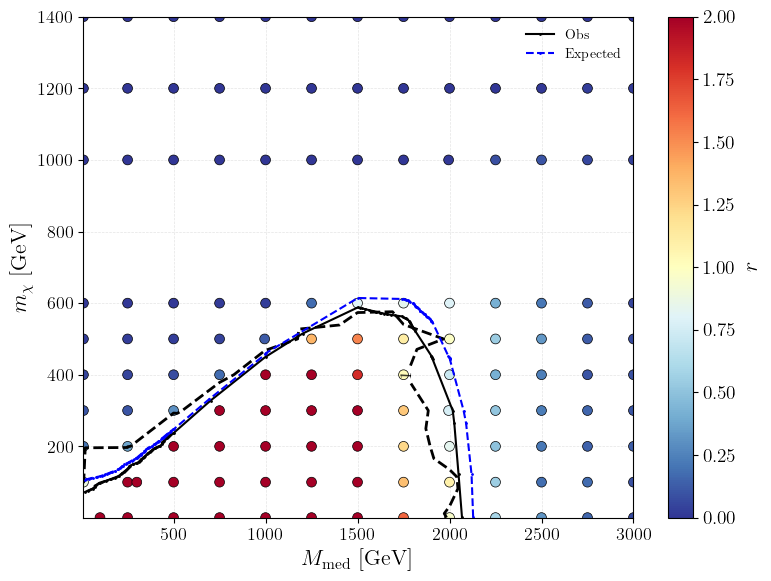

In [19]:
# signal_strength_obs
fig, ax = plt.subplots(figsize=(8,6))
# configure_axes(ax)
cm = plt.colormaps['RdYlBu_r']

scatter = ax.scatter(
    max_sigma_exp_per_saf["mMed (GeV)"],
    max_sigma_exp_per_saf["mchi (GeV)"],
    c=max_sigma_exp_per_saf['$r_{obs}$'],
    cmap=cm,
    s=50,
    edgecolor="black",
    linewidth=0.5,
    marker='o',
    vmin=0,
    vmax=2
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("$r$", fontsize=16)
cbar.ax.tick_params(labelsize=14)

# Contour for r ~ 1
x = max_sigma_exp_per_saf["mMed (GeV)"]
y = max_sigma_exp_per_saf["mchi (GeV)"]
z = max_sigma_exp_per_saf['$r_{obs}$']

xi, yi = np.meshgrid(
    np.linspace(x.min(), x.max(), 20),
    np.linspace(y.min(), y.max(), 20)
)
zi = griddata((x, y), z, (xi, yi))

# contour = ax.contour(xi, yi, zi, levels=[1], colors="black", linestyles="--", linewidths=1.5)
contour = ax.tricontour(x, y, z, levels=[1], colors="black", linestyles="--", linewidths=2)
ax.clabel(contour, inline=True, fontsize=12) #fmt="r = 1",
ax.plot(DataDF_Obs_DMA.iloc[:, 0], DataDF_Obs_DMA.iloc[:, 1], label='Obs', color='k', marker='o', linestyle='-', linewidth=1.5, markersize=1)
ax.plot(DataDF_Exp_DMA.iloc[:, 0], DataDF_Exp_DMA.iloc[:, 1], label='Expected', color='b', marker='o', linestyle='--', linewidth=1.5, markersize=1)

ax.set_xlabel(r'$M_{\rm med}$ [GeV]')
ax.set_ylabel(r'$m_{\chi}$ [GeV]')
plt.grid(True, linestyle='--', alpha=0.6)
# plt.ylim(290, 1000)
# plt.xlim(300, 2500)
ax.legend(frameon=False, loc='best')
plt.tight_layout()

plt.savefig('./figures/validation-spin1.png')
plt.show()


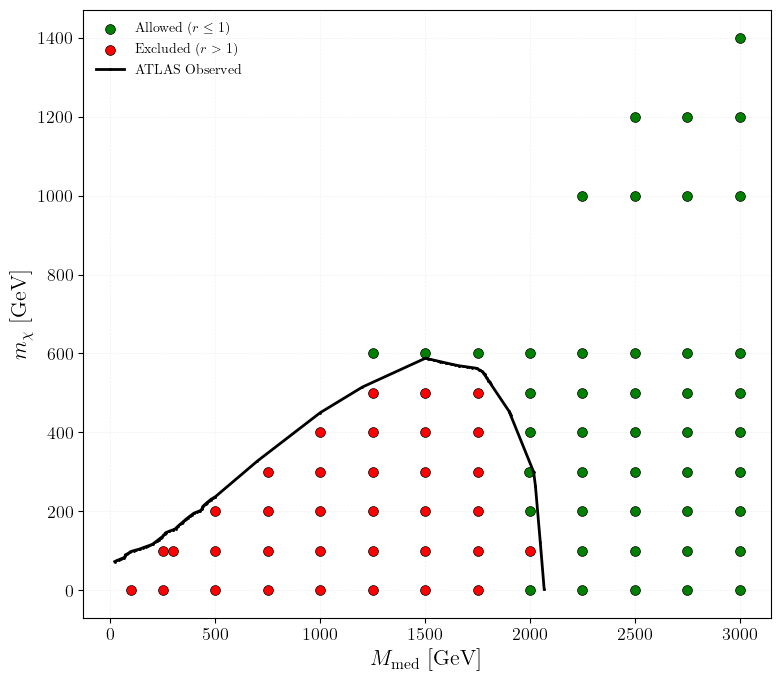

In [18]:
fig, ax = plt.subplots(figsize=(8, 7))
# configure_axes(ax)
# Add green points for r <= 1 (r Obs <= 1)
green_points = max_sigma_exp_per_saf[max_sigma_exp_per_saf['$r_{obs}$'] <= 1]
ax.scatter(
    green_points["mMed (GeV)"],
    green_points["mchi (GeV)"],
    c="green",
    label=r"Allowed ($r \leq 1$)",
    s=50,
    edgecolor="black",
    linewidth=0.5
)

# Add red points for r >  1 (r Obs > 1)
red_points = max_sigma_exp_per_saf[max_sigma_exp_per_saf['$r_{obs}$'] > 1]
ax.scatter(
    red_points["mMed (GeV)"],
    red_points["mchi (GeV)"],
    c="red",
    label=r"Excluded ($r > 1$)",
    s=50,
    edgecolor="black",
    linewidth=0.5
)

# Contour for mu ~ 1
x = max_sigma_exp_per_saf["mMed (GeV)"]
y = max_sigma_exp_per_saf["mchi (GeV)"]
z = max_sigma_exp_per_saf['$r_{obs}$']
xi, yi = np.meshgrid(
    np.linspace(x.min(), x.max(), 200),
    np.linspace(y.min(), y.max(), 200)
)
zi = griddata((x, y), z, (xi, yi), method='linear')
# contour = ax.contour(xi, yi, zi, levels=[1], colors="black", linestyles="--", linewidths=2)
# ax.clabel(contour, fmt="r = 1", inline=True, fontsize=12)
# ax.plot(hep_data_ttbnffObs['mMed [GeV]'], hep_data_ttbnffObs['mchi [GeV]'], color="black", label='ATLAS Observation', linewidth=1)
ax.plot(DataDF_Obs_DMA.iloc[:, 0], DataDF_Obs_DMA.iloc[:, 1], label=r'ATLAS Observed', color='k', marker='o', linestyle='-', linewidth=2, markersize=1)
# ax.plot(DataDF_Exp_DMA.iloc[:, 0], DataDF_Exp_DMA.iloc[:, 1], label=r'ATLAS Expected', color='b', marker='o', linestyle='--', linewidth=1.5, markersize=1)
ax.set_xlabel(r'$M_{\rm med}$ [GeV]')
ax.set_ylabel(r'$m_{\chi}$ [GeV]')
ax.legend()
plt.grid(True, linestyle='--', alpha=0.6)
# plt.ylim(10, 900)
# plt.xlim(10, 2500)
ax.legend(framealpha=0.0, loc='best')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
# plt.savefig('./plot-validation.png')

plt.show()
